In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install wandb evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
import wandb
import evaluate


In [4]:
path_dataset = '/content/drive/MyDrive/TFG/titles_data.jsonl'

with open(path_dataset, 'r', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

print(f"Total dataset shape: {df.shape}")


Total dataset shape: (2312, 3)


In [5]:
# 1. Group Shuffle Split strategy based on 'id' -> Train, Eval, Test
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42) # 70% train, 30% temp
train_idx, temp_idx = next(gss1.split(df, groups=df['group_id']))

df_train = df.iloc[train_idx].copy()
df_temp = df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42) # 15% eval, 15% test
eval_idx, test_idx = next(gss2.split(df_temp, groups=df_temp['group_id']))

df_eval = df_temp.iloc[eval_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

print(f"Train shape: {df_train.shape}, Evalu shape: {df_eval.shape}, Test shape: {df_test.shape}")

# Convert to HF Datasets
dataset_dict = DatasetDict({
    'train': Dataset.from_pandas(df_train),
    'eval': Dataset.from_pandas(df_eval),
    'test': Dataset.from_pandas(df_test)
})


Train shape: (1619, 3), Evalu shape: (346, 3), Test shape: (347, 3)


In [6]:
model_path = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_path)

id2label = {0: "IA", 1: "Human"}
label2id = {"IA": 0, "Human": 1}

def preprocess_function(examples):
    tokenized_inputs = tokenizer(examples["title"], truncation=True)
    tokenized_inputs["labels"] = examples["is_real"]
    return tokenized_inputs

tokenized_data = dataset_dict.map(preprocess_function, batched=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1619 [00:00<?, ? examples/s]

Map:   0%|          | 0/346 [00:00<?, ? examples/s]

Map:   0%|          | 0/347 [00:00<?, ? examples/s]

In [7]:
# 3. Robust metric computation
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if np.isnan(predictions).any():
        print("NaN found in predictions before probability conversion! Replacing with 0.")
        predictions = np.nan_to_num(predictions)

    predicted_classes = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predicted_classes, average='macro', zero_division=0)
    acc = accuracy_score(labels, predicted_classes)

    return {
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall
    }


In [ ]:
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'eval/f1_macro',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'distribution': 'log_uniform_values',
            'min': 1e-6,
            'max': 1e-4
        },
        'per_device_train_batch_size': {
            'values': [8, 16]
        },
        'num_train_epochs': {
            'values': [2, 3, 4, 5]
        },
        'weight_decay': {
            'values': [0.0, 0.01, 0.1]
        }
    }
}

sweep_id = wandb.sweep(sweep_config, project="TFG-RoBERTa-Detector")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: xaeybj9s
Sweep URL: https://wandb.ai/javierprior04-universidad-de-murcia/TFG-RoBERTa-Detector/sweeps/xaeybj9s


In [ ]:
def train_sweep():
    with wandb.init() as run:
        config = wandb.config

        model = AutoModelForSequenceClassification.from_pretrained(
            model_path, num_labels=2, id2label=id2label, label2id=label2id
        )

        training_args = TrainingArguments(
            output_dir="./temp_checkpoints",
            learning_rate=config.learning_rate,
            per_device_train_batch_size=config.per_device_train_batch_size,
            per_device_eval_batch_size=8,
            num_train_epochs=config.num_train_epochs,
            weight_decay=config.weight_decay,
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_f1_macro",
            greater_is_better=True,
            report_to="wandb",
            seed=42 # Added for reproducibility
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_data["train"],
            eval_dataset=tokenized_data["eval"],
            data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
            compute_metrics=compute_metrics
        )

        trainer.train()


In [ ]:
print("Starting Hyperparameter Search (Sweep)...")
wandb.agent(sweep_id, function=train_sweep, count=5)


Starting Hyperparameter Search (Sweep)...


wandb: Agent Starting Run: d9ol6fbf with config:
wandb: 	learning_rate: 5.5697667703996445e-06
wandb: 	num_train_epochs: 4
wandb: 	per_device_train_batch_size: 8
wandb: 	weight_decay: 0
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: javierprior04 (javierprior04-universidad-de-murcia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: WARNING Config item 'per_device_train_batch_size' was locked by 'sweep' (ignored update).
wand

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.550240,0.356812,0.884393,0.884254,0.886794,0.884623
2,0.383811,0.399695,0.890173,0.890115,0.891383,0.890337
3,0.320917,0.423887,0.901734,0.901731,0.901905,0.901798
4,0.287472,0.452334,0.890173,0.890170,0.890170,0.890170


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

eval/accuracy,▁▃█▃
eval/f1_macro,▁▃█▃
eval/loss,▁▄▆█
eval/precision_macro,▁▃█▃
eval/recall_macro,▁▃█▃
eval/runtime,▁▃▆█
eval/samples_per_second,█▅▃▁
eval/steps_per_second,█▅▃▁
train/epoch,▁▁▃▃▆▆███
train/global_step,▁▁▃▃▆▆███
+3,...


wandb: Agent Starting Run: xc4bt27b with config:
wandb: 	learning_rate: 6.410718241473821e-06
wandb: 	num_train_epochs: 5
wandb: 	per_device_train_batch_size: 8
wandb: 	weight_decay: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: WARNING Config item 'per_device_train_batch_size' was locked by 'sweep' (ignored update).
wand

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.516227,0.391268,0.881503,0.881144,0.887009,0.881850
2,0.361744,0.392661,0.881503,0.881502,0.881587,0.881549
3,0.295618,0.419699,0.881503,0.881494,0.881520,0.881482
4,0.249096,0.509030,0.887283,0.887282,0.887283,0.887296
5,0.233974,0.521100,0.884393,0.884389,0.884389,0.884389


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

eval/accuracy,▁▁▁█▄
eval/f1_macro,▁▁▁█▅
eval/loss,▁▁▃▇█
eval/precision_macro,█▁▁█▄
eval/recall_macro,▁▁▁█▅
eval/runtime,▁▂█▃▆
eval/samples_per_second,█▇▁▆▃
eval/steps_per_second,█▇▁▆▃
train/epoch,▁▁▃▃▅▅▆▆███
train/global_step,▁▁▃▃▅▅▆▆███
+3,...


wandb: Agent Starting Run: 2jqhvnt2 with config:
wandb: 	learning_rate: 1.3298123135798592e-05
wandb: 	num_train_epochs: 4
wandb: 	per_device_train_batch_size: 16
wandb: 	weight_decay: 0.1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: WARNING Config item 'per_device_train_batch_size' was locked by 'sweep' (ignored update).
wand

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.505843,0.339311,0.878613,0.878353,0.882591,0.878909
2,0.287443,0.289887,0.893064,0.893041,0.893637,0.893177
3,0.210399,0.339673,0.895954,0.895954,0.895984,0.895984
4,0.175792,0.370558,0.901734,0.901731,0.901731,0.901731


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

eval/accuracy,▁▅▆█
eval/f1_macro,▁▅▆█
eval/loss,▅▁▅█
eval/precision_macro,▁▅▆█
eval/recall_macro,▁▅▆█
eval/runtime,▄▃▁█
eval/samples_per_second,▅▆█▁
eval/steps_per_second,▅▆█▁
train/epoch,▁▁▃▃▆▆███
train/global_step,▁▁▃▃▆▆███
+3,...


wandb: Agent Starting Run: zp6fccl4 with config:
wandb: 	learning_rate: 1.3189479523688108e-05
wandb: 	num_train_epochs: 4
wandb: 	per_device_train_batch_size: 16
wandb: 	weight_decay: 0.1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: WARNING Config item 'per_device_train_batch_size' was locked by 'sweep' (ignored update).
wand

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.499615,0.367537,0.867052,0.866606,0.872897,0.867415
2,0.298188,0.306447,0.895954,0.895867,0.897746,0.896151
3,0.203892,0.335498,0.878613,0.878548,0.879116,0.878508
4,0.167162,0.368275,0.898844,0.898843,0.898844,0.898857


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

eval/accuracy,▁▇▄█
eval/f1_macro,▁▇▄█
eval/loss,█▁▄█
eval/precision_macro,▁█▃█
eval/recall_macro,▁▇▃█
eval/runtime,█▁▂▁
eval/samples_per_second,▁█▇█
eval/steps_per_second,▁█▇█
train/epoch,▁▁▃▃▆▆███
train/global_step,▁▁▃▃▆▆███
+3,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: jz5nd2i7 with config:
wandb: 	learning_rate: 4.584109456990218e-06
wandb: 	num_train_epochs: 5
wandb: 	per_device_train_batch_size: 8
wandb: 	weight_decay: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: WARNING Config item 'per_device_train_batch_size' was locked by 'sweep' (ignored update).
wand

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.551848,0.383267,0.869942,0.869260,0.878935,0.870389
2,0.368758,0.372621,0.887283,0.887207,0.888749,0.887463
3,0.324587,0.390232,0.901734,0.901734,0.901764,0.901764
4,0.284454,0.462583,0.898844,0.898843,0.898844,0.898857
5,0.280057,0.478813,0.893064,0.893056,0.893083,0.893043


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

eval/accuracy,▁▅█▇▆
eval/f1_macro,▁▅█▇▆
eval/loss,▂▁▂▇█
eval/precision_macro,▁▄█▇▅
eval/recall_macro,▁▅█▇▆
eval/runtime,█▅▁▁▅
eval/samples_per_second,▁▄▇█▄
eval/steps_per_second,▁▄▇█▄
train/epoch,▁▁▃▃▅▅▆▆███
train/global_step,▁▁▃▃▅▅▆▆███
+3,...


In [8]:
# 5. Final Training with Best Hyperparameters
# Sustituir con los mejores valores del Sweep tras ejecutarlo
best_config = {
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 16,
    "num_train_epochs": 4,
    "weight_decay": 0.01
}

print("Starting final training con la mejor configuracion...")
final_model = AutoModelForSequenceClassification.from_pretrained(
    model_path, num_labels=2, id2label=id2label, label2id=label2id
)

final_args = TrainingArguments(
    output_dir="./final_roberta_model",
    learning_rate=best_config["learning_rate"],
    per_device_train_batch_size=best_config["per_device_train_batch_size"],
    per_device_eval_batch_size=8,
    num_train_epochs=best_config["num_train_epochs"],
    weight_decay=best_config["weight_decay"],
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    report_to="none", # Ya no reportamos el final al sweep agent
    seed=42 # Added for reproducibility
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["eval"],
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

final_trainer.train()


Starting final training con la mejor configuracion...


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.480232,0.386948,0.881503,0.880977,0.889398,0.881917
2,0.281190,0.323407,0.887283,0.887169,0.889357,0.887497
3,0.191652,0.372757,0.890173,0.890115,0.891383,0.890337
4,0.147663,0.441846,0.887283,0.887260,0.887850,0.887396


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=408, training_loss=0.2751842713823505, metrics={'train_runtime': 102.5016, 'train_samples_per_second': 63.18, 'train_steps_per_second': 3.98, 'total_flos': 100172853774180.0, 'train_loss': 0.2751842713823505, 'epoch': 4.0})

In [ ]:
# 6. Evaluation on Test Set
test_results = final_trainer.evaluate(tokenized_data["test"])
print("Test Set Results:", test_results)


Test Set Results: {'eval_loss': 0.21816155314445496, 'eval_accuracy': 0.9221902017291066, 'eval_f1_macro': 0.9221669311224278, 'eval_precision_macro': 0.9228376580172988, 'eval_recall_macro': 0.9222476911833101, 'eval_runtime': 0.8483, 'eval_samples_per_second': 409.069, 'eval_steps_per_second': 51.87, 'epoch': 4.0}


Classification Report:
              precision    recall  f1-score   support

          IA       0.91      0.94      0.92       173
       Human       0.94      0.90      0.92       174

    accuracy                           0.92       347
   macro avg       0.92      0.92      0.92       347
weighted avg       0.92      0.92      0.92       347



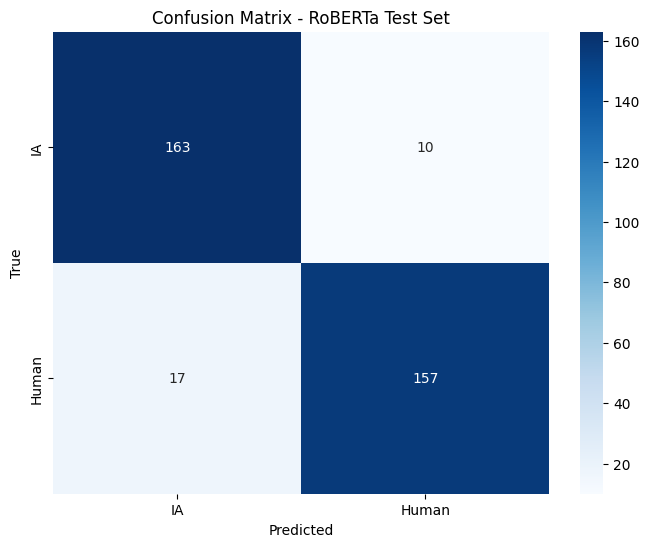

In [ ]:
# 7. Predictions, Visualizations, and Stats
predictions, labels, metrics = final_trainer.predict(tokenized_data["test"])
predicted_classes = np.argmax(predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(labels, predicted_classes, target_names=["IA", "Human"], zero_division=0))

# Confusion Matrix
cm = confusion_matrix(labels, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["IA", "Human"], yticklabels=["IA", "Human"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - RoBERTa Test Set')
plt.show()


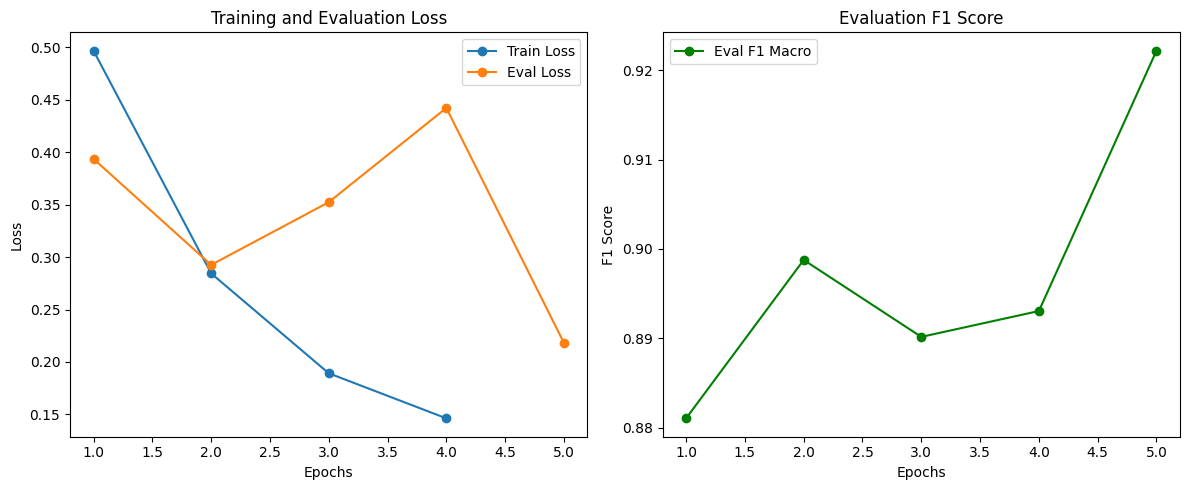

In [ ]:
# Training history visualization
log_history = final_trainer.state.log_history

train_loss = [log['loss'] for log in log_history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
eval_f1 = [log['eval_f1_macro'] for log in log_history if 'eval_f1_macro' in log]

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(range(1, len(eval_loss) + 1), eval_loss, label='Eval Loss', marker='o')
plt.title('Training and Evaluation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Eval F1
plt.subplot(1, 2, 2)
if eval_f1:
    plt.plot(range(1, len(eval_f1) + 1), eval_f1, label='Eval F1 Macro', marker='o', color='green')
    plt.title('Evaluation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()

plt.tight_layout()
plt.show()


In [23]:
import torch
import shap
import pandas as pd
import numpy as np
from transformers import pipeline

# =========== 1. PIPELINE SETUP ===========
device_id = 0 if torch.cuda.is_available() else -1

pred_pipeline = pipeline(
    "text-classification",
    model=final_model,
    tokenizer=tokenizer,
    device=device_id,
    top_k=None
)

# =========== 2. EXPLAINER INITIALIZATION ===========
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(pred_pipeline, masker=masker, algorithm="partition")

# =========== 3. SAMPLING (Reducido para velocidad) ===========
df_test_full = dataset_dict['test'].to_pandas()

print(f"Obteniendo predicciones...")
preds = pred_pipeline(df_test_full['title'].tolist(), batch_size=16)

pred_labels = []
for p in preds:
    best_pred = max(p, key=lambda x: x['score'])
    pred_labels.append(0 if best_pred['label'] == 'IA' else 1)
df_test_full['pred_label'] = pred_labels

subset_tp = df_test_full[(df_test_full['is_real'] == 0) & (df_test_full['pred_label'] == 0)]
subset_tn = df_test_full[(df_test_full['is_real'] == 1) & (df_test_full['pred_label'] == 1)]
subset_fp = df_test_full[(df_test_full['is_real'] == 1) & (df_test_full['pred_label'] == 0)]
subset_fn = df_test_full[(df_test_full['is_real'] == 0) & (df_test_full['pred_label'] == 1)]

# Reducimos a 5 muestras por categoría (Total 20) para que termine rápido en Colab
samples = []
for df_sub in [subset_tp, subset_tn, subset_fp, subset_fn]:
    samples.append(df_sub.sample(min(len(df_sub), 50), random_state=42))

sample_df = pd.concat(samples).drop_duplicates()
sample_texts = sample_df['title'].tolist()
print(f"Muestra lista: {len(sample_texts)} textos seleccionados.")

Obteniendo predicciones...
Muestra lista: 125 textos seleccionados.


Generando SHAP values (esto puede tardar unos minutos)... Aunque parezca parado, está trabajando.


  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer:  17%|█▋        | 21/125 [01:07<05:35,  3.23s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  18%|█▊        | 22/125 [01:13<06:45,  3.93s/it]

  0%|          | 0/462 [00:00<?, ?it/s]

PartitionExplainer explainer:  19%|█▉        | 24/125 [01:20<06:23,  3.79s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  23%|██▎       | 29/125 [01:38<05:24,  3.38s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  26%|██▋       | 33/125 [01:52<04:52,  3.18s/it]

  0%|          | 0/462 [00:00<?, ?it/s]

PartitionExplainer explainer:  32%|███▏      | 40/125 [02:19<05:32,  3.91s/it]

  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer:  34%|███▍      | 43/125 [02:31<04:57,  3.63s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  35%|███▌      | 44/125 [02:36<05:38,  4.17s/it]

  0%|          | 0/380 [00:00<?, ?it/s]

PartitionExplainer explainer:  38%|███▊      | 47/125 [02:46<04:22,  3.37s/it]

  0%|          | 0/462 [00:00<?, ?it/s]

PartitionExplainer explainer:  41%|████      | 51/125 [03:02<04:43,  3.83s/it]

  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer:  47%|████▋     | 59/125 [03:32<03:55,  3.57s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  51%|█████     | 64/125 [03:48<02:57,  2.91s/it]

  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer:  52%|█████▏    | 65/125 [03:55<04:19,  4.33s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  55%|█████▌    | 69/125 [04:10<02:56,  3.16s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  70%|███████   | 88/125 [05:11<01:36,  2.61s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  77%|███████▋  | 96/125 [05:37<01:32,  3.19s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  90%|████████▉ | 112/125 [06:29<00:42,  3.27s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  94%|█████████▎| 117/125 [06:46<00:24,  3.04s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  97%|█████████▋| 121/125 [06:59<00:12,  3.15s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 126it [07:18,  3.57s/it]



[A] Visualización individual (Ejemplo IA):


None


[B] Importancia global de tokens:


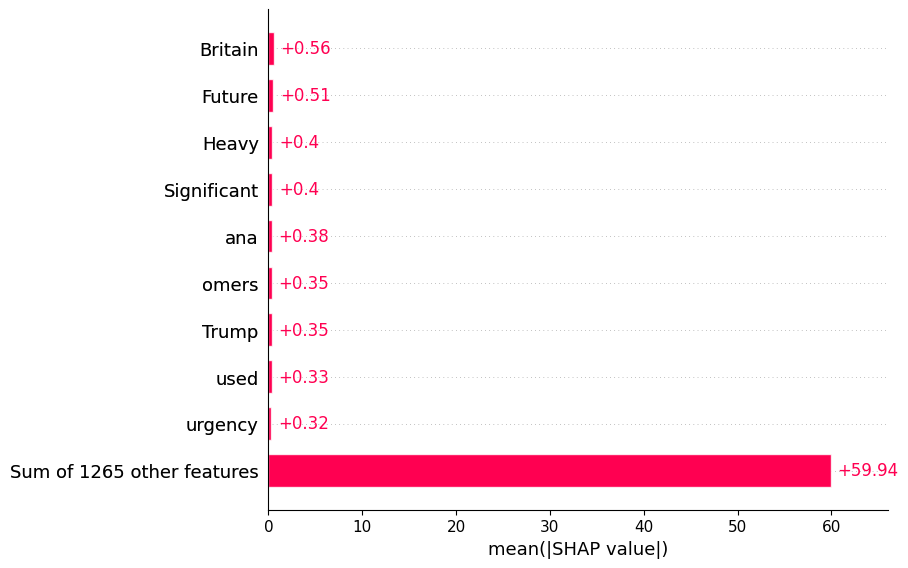

In [24]:
# =========== 4. COMPUTATION ===========
print("Generando SHAP values (esto puede tardar unos minutos)... Aunque parezca parado, está trabajando.")
# Calculamos los valores
shap_values = explainer(sample_texts)

# Creamos una copia de la data para poder modificarla (evitando el error de tupla)
new_data = list(shap_values.data)
for i in range(len(new_data)):
    new_data[i] = np.array([str(t).replace("Ġ", " ") for t in new_data[i]])

# Reasignamos los datos limpios al objeto shap_values
shap_values.data = np.array(new_data, dtype=object)

class_ia_idx = "IA" if "IA" in shap_values.output_names else 0

# =========== 5. VISUALIZATION ===========
shap.initjs()

synthetic_loc_idx = sample_df['is_real'].tolist().index(0)
print(f"\n[A] Visualización individual (Ejemplo IA):")
import IPython
IPython.display.display(shap.plots.text(shap_values[synthetic_loc_idx, :, class_ia_idx]))

print("\n[B] Importancia global de tokens:")
shap.plots.bar(shap_values[:, :, class_ia_idx], max_display=10, show=True)


[A] Render de Explicación Textual - Observación en Submuestra: #0


None


[B] Resumen global de importancia de tokens:


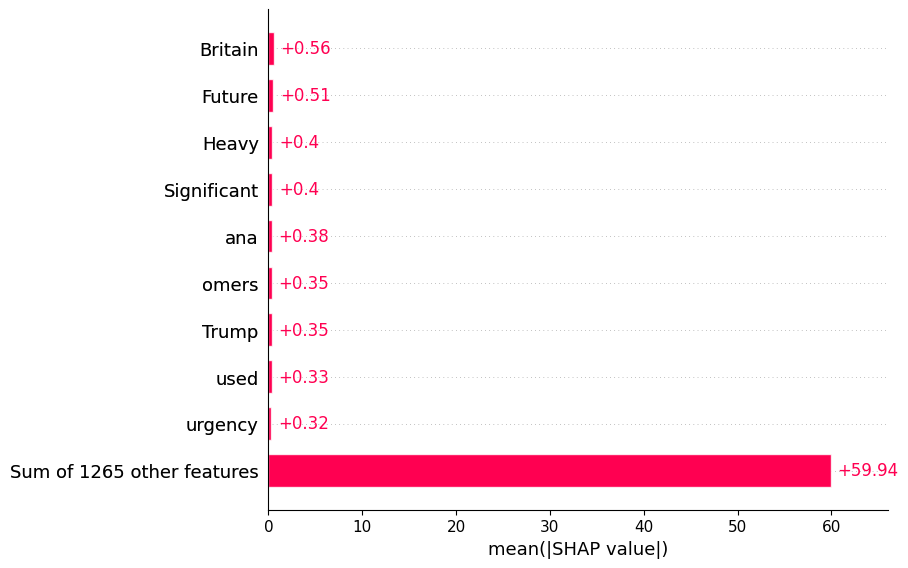


Exportando tokens principales al CSV 'shap_impact_gemini_tokens.csv'...

(Extracto) - TOP 5 Palabras que empujan el score a 'Sintético' (IA):
    token  mean_impact_ia  abs_impact_ia  appearances
84   amid        0.254587       0.254587            8
863   san        0.241906       0.241906            3
321   dri        0.211115       0.211115            2
937  stre        0.194806       0.194806            2
546  iran        0.191800       0.191996            4


In [27]:
# =========== 5. VISUALIZATION & INSIGHTS ===========
# Activamos JavaScript para que las salidas de la celda de Jupyter funcionen
shap.initjs()

try:
    # A. Gráfico Textual Individual
    synthetic_loc_idx = sample_df['is_real'].tolist().index(0)

    # Detectar el índice de la clase IA
    if isinstance(class_ia_idx, str) and hasattr(shap_values, 'output_names') and shap_values.output_names is not None:
        actual_idx = list(shap_values.output_names).index(class_ia_idx)
    else:
        actual_idx = 0

    print(f"\n[A] Render de Explicación Textual - Observación en Submuestra: #{synthetic_loc_idx}")
    import IPython
    # Usamos el slicing del objeto de explicación directamente
    exp_slice = shap_values[synthetic_loc_idx, :, actual_idx] if len(shap_values.shape) == 3 else shap_values[synthetic_loc_idx]
    IPython.display.display(shap.plots.text(exp_slice))

    # B. Gráfico Global de Barras
    print("\n[B] Resumen global de importancia de tokens:")
    # Para el gráfico global, extraemos la clase objetivo si existe la dimensión
    if len(shap_values.shape) == 3:
        global_exp = shap_values[:, :, actual_idx]
    else:
        global_exp = shap_values

    # Forzamos un bar plot del objeto de explicación global
    shap.plots.bar(global_exp, max_display=10)

    # =========== 6. EXPORT / DATA TABULATION ===========
    print("\nExportando tokens principales al CSV 'shap_impact_gemini_tokens.csv'...")
    token_data = []

    # Iterar sobre el objeto de explicación para extraer datos limpios
    for i in range(global_exp.shape[0]):
        tks = global_exp.data[i]
        vals = global_exp.values[i]
        for t_raw, v in zip(tks, vals):
            t_clean = str(t_raw).strip().lower()
            if len(t_clean) > 1:
                token_data.append({'token': t_clean, 'impact_ia': float(v)})

    df_tokens = pd.DataFrame(token_data)
    df_shap_export = df_tokens.groupby('token').agg(
        mean_impact_ia=('impact_ia', 'mean'),
        abs_impact_ia=('impact_ia', lambda x: np.mean(np.abs(x))),
        appearances=('impact_ia', 'count')
    ).reset_index()

    df_shap_export = df_shap_export[df_shap_export['appearances'] > 1]
    df_shap_export = df_shap_export.sort_values(by='mean_impact_ia', ascending=False)
    df_shap_export.to_csv("shap_impact_gemini_tokens.csv", index=False)

    print("\n(Extracto) - TOP 5 Palabras que empujan el score a 'Sintético' (IA):")
    print(df_shap_export.head(5))
except Exception as e:
    print(f"Ha ocurrido un error inesperado: {e}")